<h2>About the Dataset</h2>
<h4>The Car Features and MSRP Datasetcontains data about various car models, their specifications, and their prices (MSRP — Manufacturer’s Suggested Retail Price).</h4>


<h2>Problem Statements </h2>
<h4> 1. Predict the MSRP (price) of a car based on its technical specifications.<br>
2. Predict whether a car is “Luxury” or “Non-Luxury” based on its price segment and specs.<br>
3. Group cars into segments (e.g., Economy, Mid-range, Luxury) based on performance and efficiency.</h4>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
df = pd.read_csv("automobile_data.csv")

In [ ]:
df

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [ ]:
df.nunique()

,0
Make,48
Model,915
Year,28
Engine Fuel Type,10
Engine HP,356
Engine Cylinders,9
Transmission Type,5
Driven_Wheels,4
Number of Doors,3
Market Category,71


In [ ]:
for col in df.columns:
    print(f"Value counts for column: {col}")
    print(df[col].value_counts())
    print("-" * 40)


Value counts for column: Make
Make
Chevrolet        1123
Ford              881
Volkswagen        809
Toyota            746
Dodge             626
Nissan            558
GMC               515
Honda             449
Mazda             423
Cadillac          397
Mercedes-Benz     353
Suzuki            351
BMW               334
Infiniti          330
Audi              328
Hyundai           303
Volvo             281
Subaru            256
Acura             252
Kia               231
Mitsubishi        213
Lexus             202
Buick             196
Chrysler          187
Pontiac           186
Lincoln           164
Oldsmobile        150
Land Rover        143
Porsche           136
Saab              111
Aston Martin       93
Plymouth           82
Bentley            74
Ferrari            69
FIAT               62
Scion              60
Maserati           58
Lamborghini        52
Rolls-Royce        31
Lotus              29
Tesla              18
HUMMER             17
Maybach            16
Alfa Romeo         

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [ ]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [ ]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
Engine Fuel Type,3
Engine HP,69
Engine Cylinders,30
Transmission Type,0
Driven_Wheels,0
Number of Doors,6
Market Category,3742


<h4> Handling Missing Values </h4>  
<h6> For numeric columns → fill with mean/median.</h6>

In [ ]:
df['Engine HP'].fillna(df['Engine HP'].mean(), inplace=True)

/tmp/ipython-input-2846301960.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Engine HP'].fillna(df['Engine HP'].mean(), inplace=True)


<h6>Even though we can see that engine Cylinder has numerical entry but we are treating it as categorical discrete value becaue we view cylinder count as a category-like feature (e.g., “4-cylinder”, “6-cylinder” engine types)
and want to preserve the realistic, existing values rather than fractional averages like 5.6</h6>

In [ ]:
df['Engine Cylinders'].fillna(df['Engine Cylinders'].mode()[0], inplace=True)

/tmp/ipython-input-4001454442.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Engine Cylinders'].fillna(df['Engine Cylinders'].mode()[0], inplace=True)


<h5>Dropping Unnecessary Columns </h5>

In [ ]:
df.drop(['Model', 'Market Category'], axis=1, inplace=True)

In [ ]:
df.isnull().sum()

,0
Make,0
Year,0
Engine Fuel Type,3
Engine HP,0
Engine Cylinders,0
Transmission Type,0
Driven_Wheels,0
Number of Doors,6
Vehicle Size,0
Vehicle Style,0


<h3>Encoding Categorical Variables </h3>

In [ ]:
df.nunique()

,0
Make,48
Year,28
Engine Fuel Type,10
Engine HP,357
Engine Cylinders,9
Transmission Type,5
Driven_Wheels,4
Number of Doors,3
Vehicle Size,3
Vehicle Style,16


<h4>Encoding columns :  Make, Transmission Type, Driven_Wheels, Fuel_Type </h4>

In [ ]:
# Frequency Encoding for 'Make'
freq_map = df['Make'].value_counts().to_dict()
df['Make'] = df['Make'].map(freq_map)

In [ ]:
#One-Hot Encoding for small categorical features
categorical_cols = ['Transmission Type', 'Driven_Wheels', 'Engine Fuel Type']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

<h3>Outlier Detection </h3>
<h6>MSRP, Engine HP, and Popularity often have extreme outliers

Outliers can heavily skew regression models thus ,
capping them at reasonable thresholds helps models generalize better.</h6>

In [ ]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

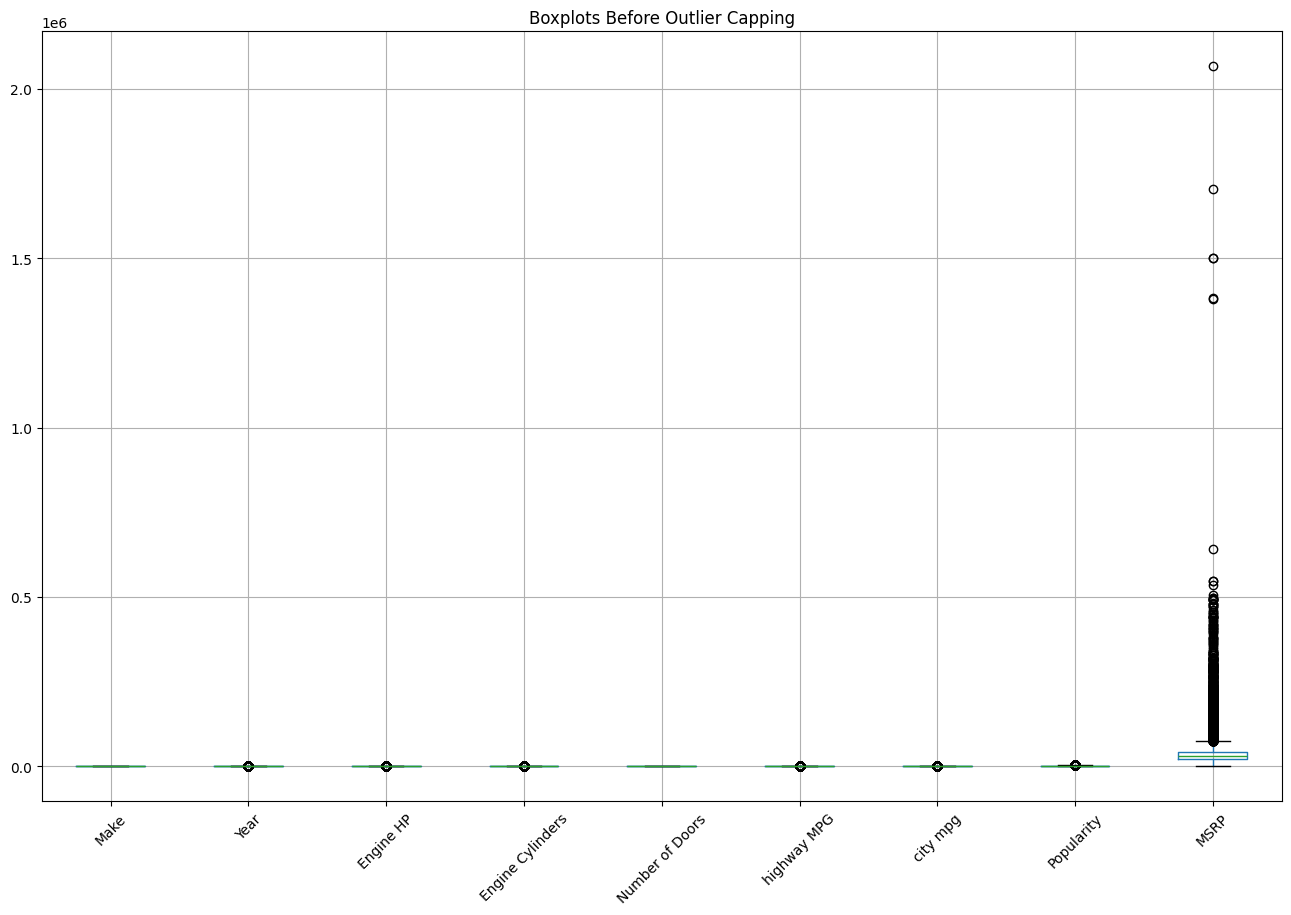

In [ ]:
plt.figure(figsize=(16, 10))
df[numeric_cols].boxplot(rot=90)
plt.title("Boxplots Before Outlier Capping")
plt.xticks(rotation=45)
plt.show()

In [ ]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Cap values outside limits
    df[col] = np.where(df[col] > upper, upper,
              np.where(df[col] < lower, lower, df[col]))


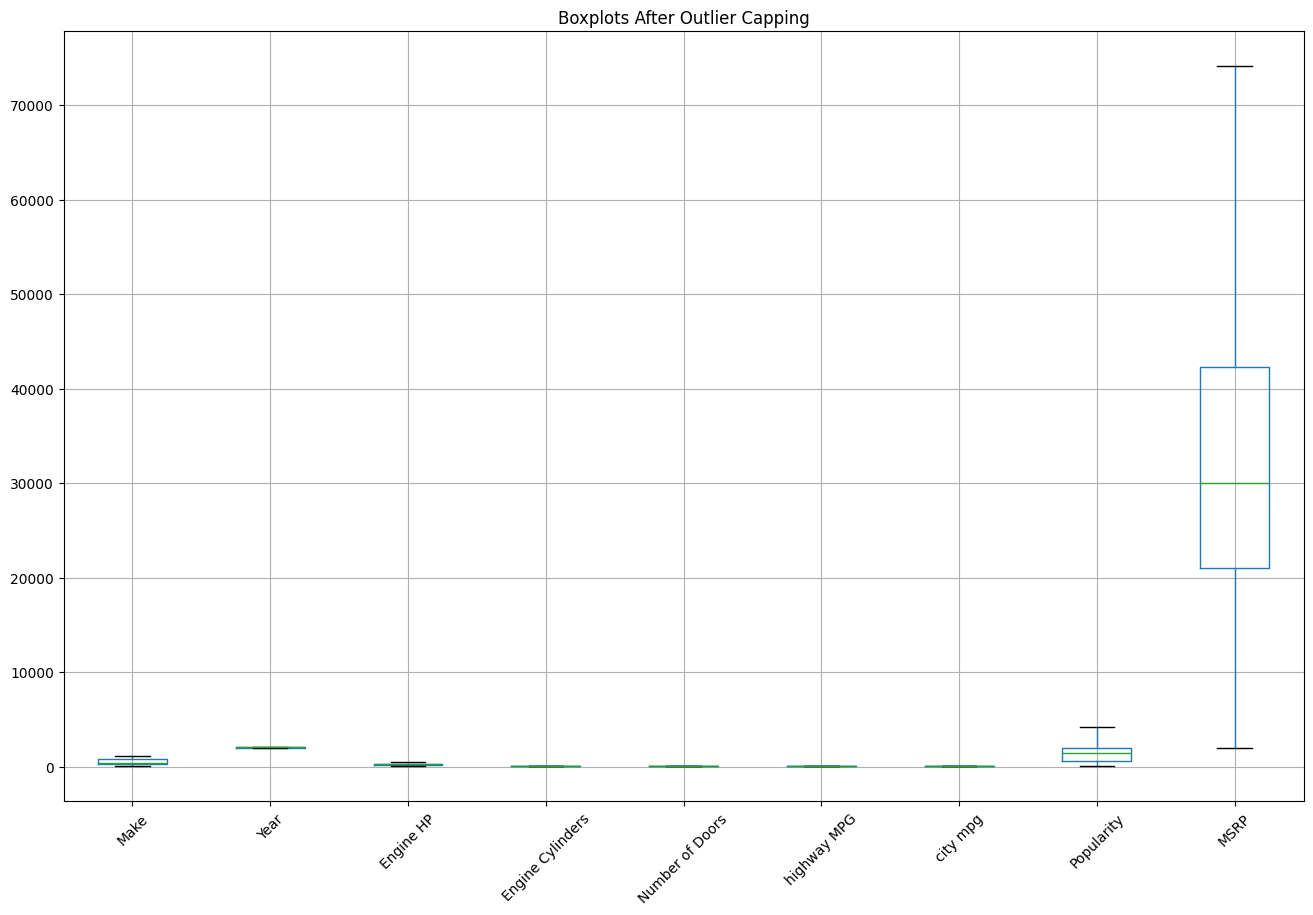

In [ ]:
plt.figure(figsize=(16, 10))
df[numeric_cols].boxplot(rot=90)
plt.title("Boxplots After Outlier Capping")
plt.xticks(rotation=45)
plt.show()

<h3>Feature Selection</h3>

<h6>Filter Out Highly Correlated Features
(for regression and clustering)

Drop one of any pair with correlation > 0.9.</h6>

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix only for numeric features
corr_matrix = numeric_df.corr().abs()

# Find highly correlated features
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Highly correlated features to drop:", to_drop)

# Drop them from the main DataFrame
df.drop(columns=to_drop, inplace=True)

Highly correlated features to drop: ['city mpg']


<h5>city mpg and highway MPG are often strongly correlated → keeping only one</h5>

<h4>Remove Low-Variance Features(for encoded categorical variables)

Features that barely change across rows add no value.</h4>

In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)  # you can tune this threshold
numeric_df_var = pd.DataFrame(
    selector.fit_transform(numeric_df),
    columns=numeric_df.columns[selector.get_support()]
)

print(f"Shape before variance filter: {numeric_df.shape}")
print(f"Shape after variance filter: {numeric_df_var.shape}")

Shape before variance filter: (11914, 9)
Shape after variance filter: (11914, 9)


<h6>It means none of the numeric columns had low variance as each of them carry useful information and aren’t constant</h6>

<h3>Feature Scaling </h3>

In [ ]:
from sklearn.preprocessing import StandardScaler
df_unscaled = df.copy()

X = df.select_dtypes(include=['float64', 'int64']).drop(columns=['MSRP'], errors='ignore')
y = df['MSRP']

X = X.dropna()
y = y.loc[X.index]

#applying log transformations
y_log = np.log1p(y)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


In [ ]:
print(X_scaled.head())

       Make      Year  Engine HP  Engine Cylinders  Number of Doors  \
0 -0.556478  0.070732   0.900309          0.276063        -1.629557   
1 -0.556478  0.070732   0.546156          0.276063        -1.629557   
2 -0.556478  0.070732   0.546156          0.276063        -1.629557   
3 -0.556478  0.070732  -0.162150          0.276063        -1.629557   
4 -0.556478  0.070732  -0.162150          0.276063        -1.629557   

   highway MPG  Popularity  
0    -0.039384    2.132612  
1     0.279764    2.132612  
2     0.279764    2.132612  
3     0.279764    2.132612  
4     0.279764    2.132612  


<h2>Linear Regression</h2>
<h6>Predicting the car prices (MSRP column)</h6>

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_log, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and train model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)


LinearRegression()

In [ ]:
total_missing_percent = (X.isna().sum().sum() / (X.shape[0] * X.shape[1])) * 100
print(f"Total missing percentage: {total_missing_percent:.2f}%")


Total missing percentage: 0.00%


In [ ]:
y_pred = lin_reg.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


MSE: 0.21
R² Score: 0.80


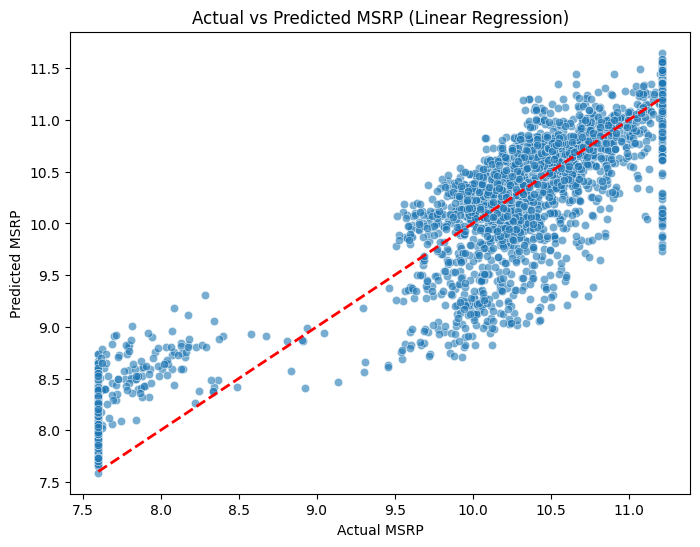

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual MSRP")
plt.ylabel("Predicted MSRP")
plt.title("Actual vs Predicted MSRP (Linear Regression)")

# Add reference line (perfect predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.show()

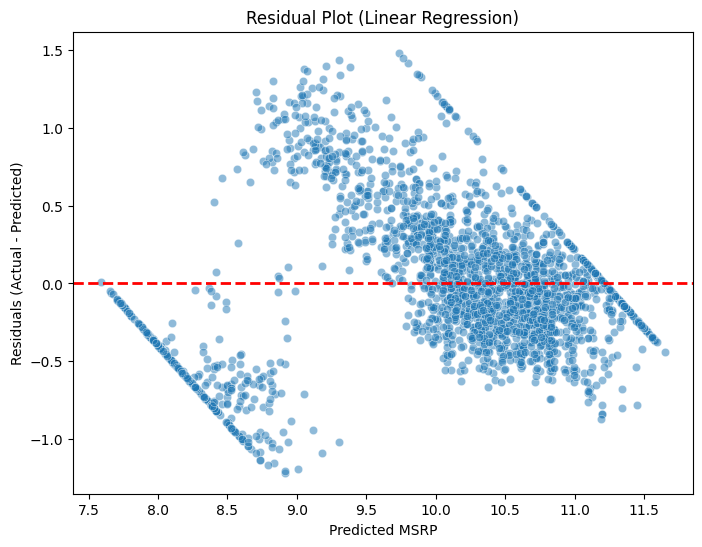

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel("Predicted MSRP")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Linear Regression)")
plt.show()


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [ ]:
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_poly_train, y_train)

LinearRegression()

In [ ]:
y_pred_poly = lin_reg_poly.predict(X_poly_test)

In [ ]:
r2_poly = r2_score(y_test, y_pred_poly)
print(f"R² Score: {r2_poly:.4f}")


R² Score: 0.9050


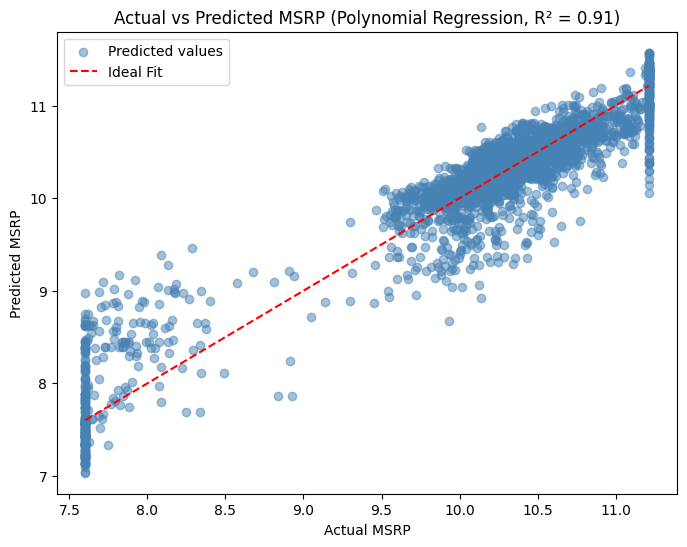

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_poly, color='steelblue', alpha=0.5, label="Predicted values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label="Ideal Fit")
plt.xlabel("Actual MSRP")
plt.ylabel("Predicted MSRP")
plt.title(f"Actual vs Predicted MSRP (Polynomial Regression, R² = {r2_poly:.2f})")
plt.legend()
plt.show()

<h5>Ridge handles correlated numeric predictors better.
the dataset has a mix of numeric features (like horsepower, weight, MPG, etc.), many of which are correlated — e.g., horsepower ↔ engine size, weight ↔ fuel efficiency.</h5>

In [ ]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)  # You can tune alpha using GridSearchCV
ridge.fit(X_train, y_train)

# Predictions
y_pred_ridge = ridge.predict(X_test)

# Evaluation
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results:")
print(f"R²: {r2_ridge:.3f}")

Ridge Regression Results:
R²: 0.798


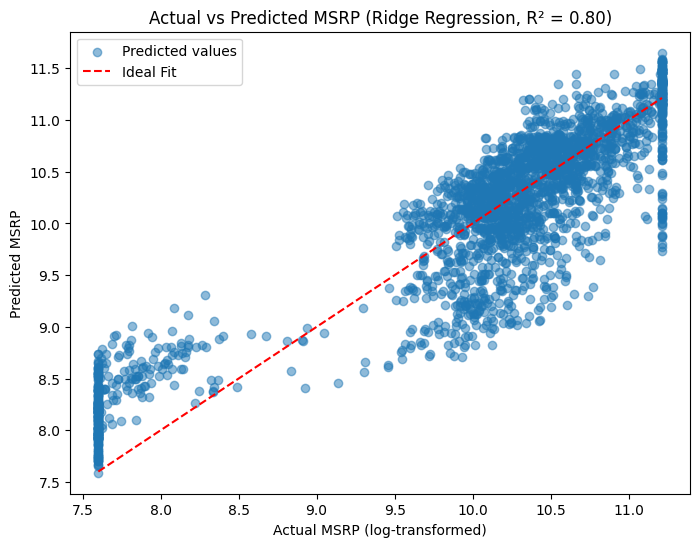

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.5, label='Predicted values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
plt.title(f'Actual vs Predicted MSRP (Ridge Regression, R² = {r2_ridge:.2f})')
plt.xlabel("Actual MSRP (log-transformed)")
plt.ylabel("Predicted MSRP")
plt.legend()
plt.show()

<h5>Lasso is useful to simplify the
model and drop redundant ones.</h5>

In [ ]:
from sklearn.linear_model import Lasso

# Lasso Regression
lasso = Lasso(alpha=0.01, max_iter=10000)  # Smaller alpha = less regularization
lasso.fit(X_train, y_train)

# Predictions
y_pred_lasso = lasso.predict(X_test)

# Evaluation
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Results:")
print(f"R²: {r2_lasso:.3f}")
print(f"MSE: {mse_lasso:.2f}")

Lasso Regression Results:
R²: 0.797
MSE: 0.21


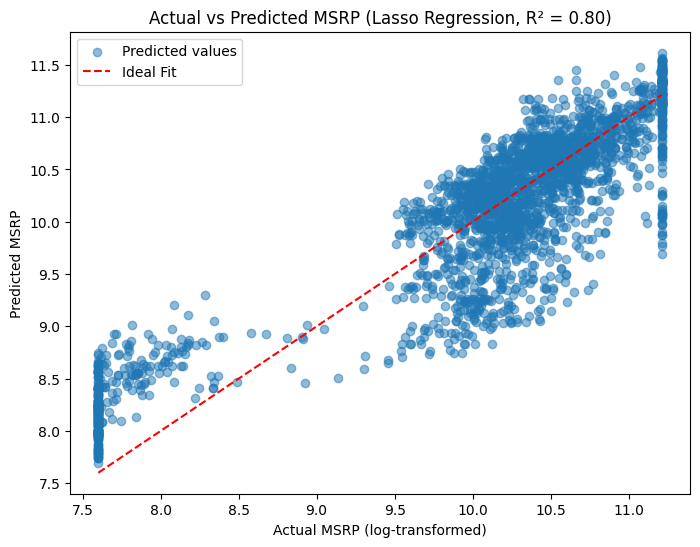

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lasso, alpha=0.5, label='Predicted values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
plt.title(f'Actual vs Predicted MSRP (Lasso Regression, R² = {r2_lasso:.2f})')
plt.xlabel("Actual MSRP (log-transformed)")
plt.ylabel("Predicted MSRP")
plt.legend()
plt.show()

<h5>Since the regularization models (Ridge/Lasso) don’t improve performance, it suggests that :
The linear model has reached its limit in capturing non-linear patterns.

It might beneficial to use **Gradient Boosting**, which can handle complex non-linear relationships and interactions between variables automatically.</h5>

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(
    n_estimators=300,     # Number of trees
    learning_rate=0.05,   # Smaller = slower but better generalization
    max_depth=4,          # Tree depth
    random_state=42
)
gb.fit(X_train, y_train)

# Predictions
y_pred_gb = gb.predict(X_test)

# Evaluation
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results:")
print(f"R²: {r2_gb:.3f}")
print(f"MSE: {mse_gb:.2f}")


Gradient Boosting Results:
R²: 0.983
MSE: 0.02


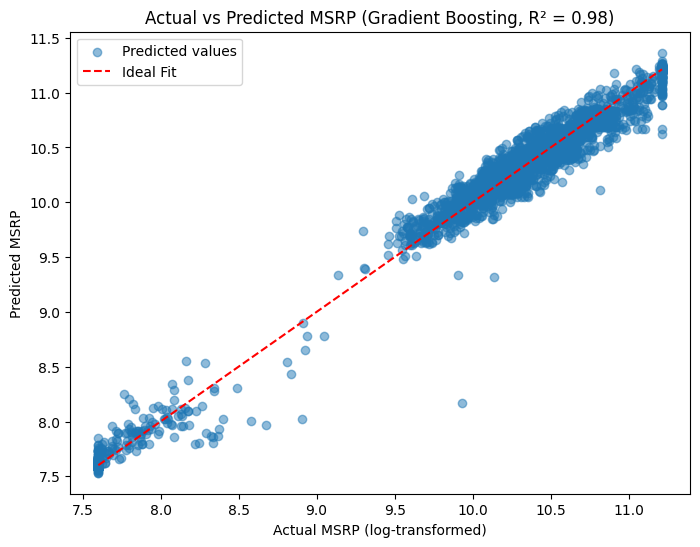

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_gb, alpha=0.5, label='Predicted values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
plt.title(f'Actual vs Predicted MSRP (Gradient Boosting, R² = {r2_gb:.2f})')
plt.xlabel("Actual MSRP (log-transformed)")
plt.ylabel("Predicted MSRP")
plt.legend()
plt.show()

<h2>Classification </h2>

<h3>1. Predict the type of fuel a car uses (e.g., Gasoline, Diesel, Electric, Hybrid) based on its specifications.</h3>

In [ ]:
print(df_unscaled.columns.tolist())


['Make', 'Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'Vehicle Size', 'Vehicle Style', 'highway MPG', 'Popularity', 'MSRP', 'Transmission Type_AUTOMATIC', 'Transmission Type_DIRECT_DRIVE', 'Transmission Type_MANUAL', 'Transmission Type_UNKNOWN', 'Driven_Wheels_four wheel drive', 'Driven_Wheels_front wheel drive', 'Driven_Wheels_rear wheel drive', 'Engine Fuel Type_electric', 'Engine Fuel Type_flex-fuel (premium unleaded recommended/E85)', 'Engine Fuel Type_flex-fuel (premium unleaded required/E85)', 'Engine Fuel Type_flex-fuel (unleaded/E85)', 'Engine Fuel Type_flex-fuel (unleaded/natural gas)', 'Engine Fuel Type_natural gas', 'Engine Fuel Type_premium unleaded (recommended)', 'Engine Fuel Type_premium unleaded (required)', 'Engine Fuel Type_regular unleaded']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
# --- Step 1: Recreate a single fuel-type label from one-hot columns ---
fuel_cols = [col for col in df.columns if col.startswith('Engine Fuel Type_')]

# Find which dummy col has value 1 for each row
df['Fuel_Type_Label'] = df[fuel_cols].idxmax(axis=1)

# Clean the name (remove prefix)
df['Fuel_Type_Label'] = df['Fuel_Type_Label'].str.replace('Engine Fuel Type_', '')

# --- Step 2: Define features and target ---
y_fuel = df['Fuel_Type_Label']
X_fuel = df.drop(columns=fuel_cols + ['Fuel_Type_Label', 'MSRP'], errors='ignore')

# Encode target
from sklearn.preprocessing import LabelEncoder
le_fuel = LabelEncoder()
y_fuel_encoded = le_fuel.fit_transform(y_fuel)

# One-hot encode remaining categoricals
X_fuel = pd.get_dummies(X_fuel, drop_first=True)

# --- Step 3: Train/test split ---
from sklearn.model_selection import train_test_split
X_train_fuel, X_test_fuel, y_train_fuel, y_test_fuel = train_test_split(
    X_fuel, y_fuel_encoded, test_size=0.2, random_state=42, stratify=y_fuel_encoded
)

# --- Step 4: Train a Random-Forest classifier ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

rf_fuel = RandomForestClassifier(n_estimators=200, random_state=42)
rf_fuel.fit(X_train_fuel, y_train_fuel)
y_pred_fuel = rf_fuel.predict(X_test_fuel)

# --- Step 5: Evaluation ---
print("Accuracy:", accuracy_score(y_test_fuel, y_pred_fuel))
print("\nClassification Report:\n",
      classification_report(y_test_fuel, y_pred_fuel,
                            labels=np.unique(y_test_fuel),  # only present classes
                            target_names=le_fuel.inverse_transform(np.unique(y_test_fuel))))



Accuracy: 0.9752412924884599

Classification Report:
                                               precision    recall  f1-score   support

                                    electric       1.00      1.00      1.00        45
flex-fuel (premium unleaded recommended/E85)       1.00      1.00      1.00         5
   flex-fuel (premium unleaded required/E85)       0.82      0.82      0.82        11
                    flex-fuel (unleaded/E85)       0.94      0.91      0.92       180
            flex-fuel (unleaded/natural gas)       1.00      1.00      1.00         1
              premium unleaded (recommended)       0.98      0.96      0.97       305
                 premium unleaded (required)       0.96      0.97      0.96       402
                            regular unleaded       0.98      0.99      0.99      1434

                                    accuracy                           0.98      2383
                                   macro avg       0.96      0.96      0.96      238

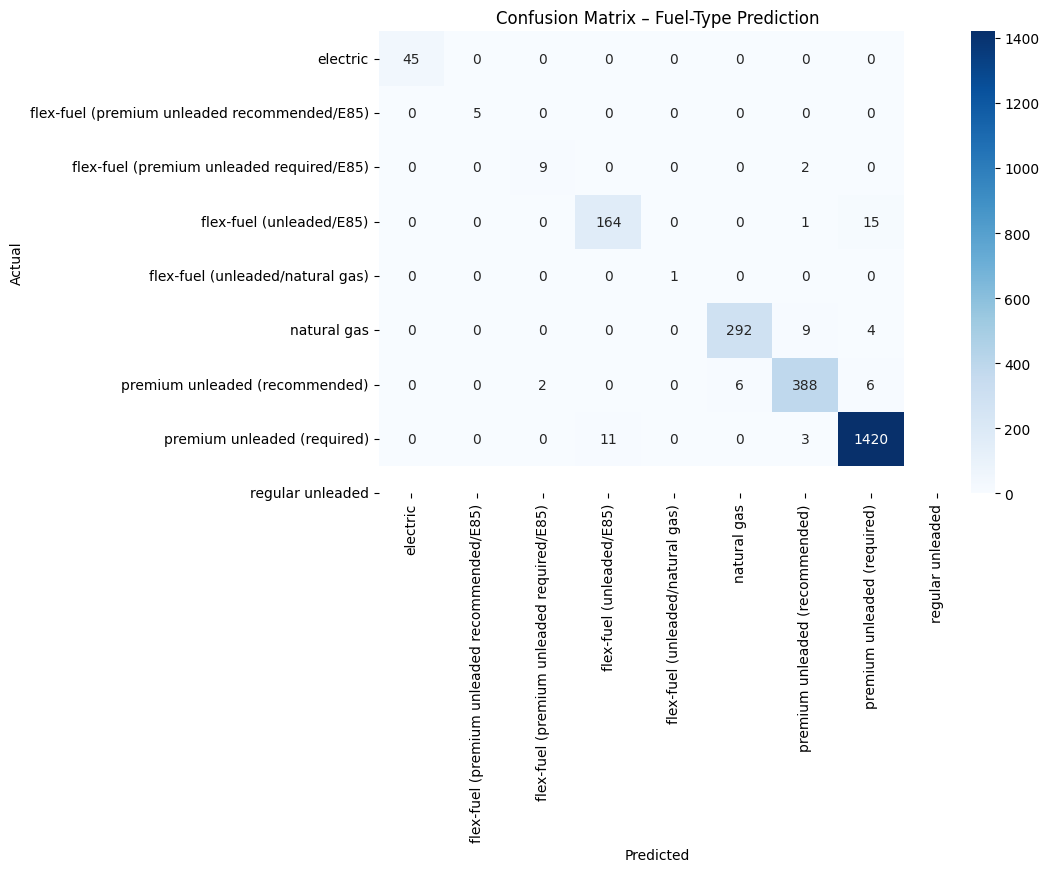

In [ ]:
plt.figure(figsize=(9,6))
sns.heatmap(confusion_matrix(y_test_fuel, y_pred_fuel),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=le_fuel.classes_,
            yticklabels=le_fuel.classes_)
plt.title("Confusion Matrix – Fuel-Type Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<h4>2.Predict Luxury vs Non-Luxury</h4>

In [ ]:
# Define luxury as cars priced above 75th percentile of MSRP
luxury_threshold = df['MSRP'].quantile(0.75)
df['Luxury'] = np.where(df['MSRP'] > luxury_threshold, 1, 0)

print(df['Luxury'].value_counts())


Luxury
0    8935
1    2979
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_class = X_scaled.copy()
y_class = df.loc[X_scaled.index, 'Luxury']

X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8421494542401343

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90      1787
           1       0.74      0.57      0.64       595

    accuracy                           0.84      2382
   macro avg       0.80      0.75      0.77      2382
weighted avg       0.83      0.84      0.83      2382


Confusion Matrix:
 [[1668  119]
 [ 257  338]]


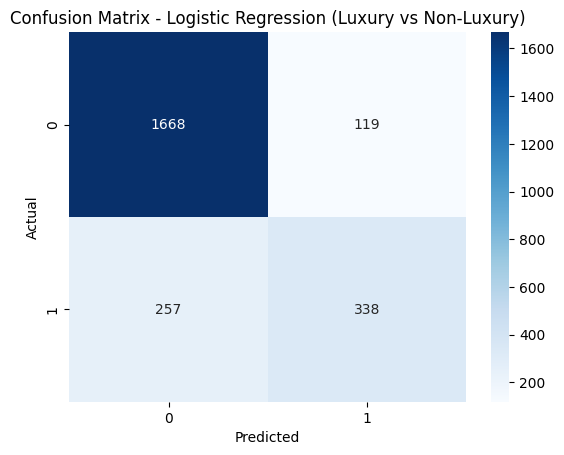

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (Luxury vs Non-Luxury)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


<h5>Accuracy: 0.84	Model correctly predicts 84% of all cases

Precision (Luxury = 1): 0.74	When model predicts “Luxury,” it’s correct 74% of the time

Recall (Luxury = 1): 0.57	Model catches only 57% of true luxury cars	Therefore , Model is missing many luxury cars.

From the confusion matrix we can infer that , Model slightly biased toward predicting “Non-Luxury".

Thus we will try other methods to improve the accuracy.</h5>

<h4>Moving from a simple linear model to a tree-based model that handles imbalance and non-linearity better

1. Random Forest
2. Gradient Boosting
3. XGBoost
</h4>

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.8963056255247691
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      1787
           1       0.77      0.84      0.80       595

    accuracy                           0.90      2382
   macro avg       0.86      0.88      0.87      2382
weighted avg       0.90      0.90      0.90      2382



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(random_state=42)
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))


Gradient Boosting Accuracy: 0.8837111670864819
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      1787
           1       0.81      0.70      0.75       595

    accuracy                           0.88      2382
   macro avg       0.86      0.82      0.84      2382
weighted avg       0.88      0.88      0.88      2382



In [ ]:
from xgboost import XGBClassifier

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train[y_train == 0]) / len(y_train[y_train == 1])),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:56:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8849706129303107

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.88      0.92      1787
           1       0.72      0.90      0.80       595

    accuracy                           0.88      2382
   macro avg       0.84      0.89      0.86      2382
weighted avg       0.90      0.88      0.89      2382


Confusion Matrix:
 [[1575  212]
 [  62  533]]


<h4>XGBoost sacrificed some precision but dramatically improved recall — meaning:

It’s predicting more cars as luxury (sometimes incorrectly), but it’s catching almost every real luxury car.

This is ideal when missing a luxury car is worse than a false alarm — e.g., in pricing, recommendation, or insurance prediction tasks</h4>

<h5>XGBoost gives the best sensitivity (recall) and solid overall performance.</h5>
<h5>Random Forest gives the most balanced performance (slightly higher precision).
<h5>Gradient Boosting is decent but not adding unique benefits here.</h5>

<h2>Clustering</h2>

<h3>Group cars into segments (e.g., Economy, Mid-range, Luxury) based on performance and efficiency.</h3>


In [ ]:
features = ['Engine HP', 'Engine Cylinders', 'highway MPG', 'MSRP', 'Popularity']
X_cluster = df[features].dropna()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scale = scaler.fit_transform(X_cluster)


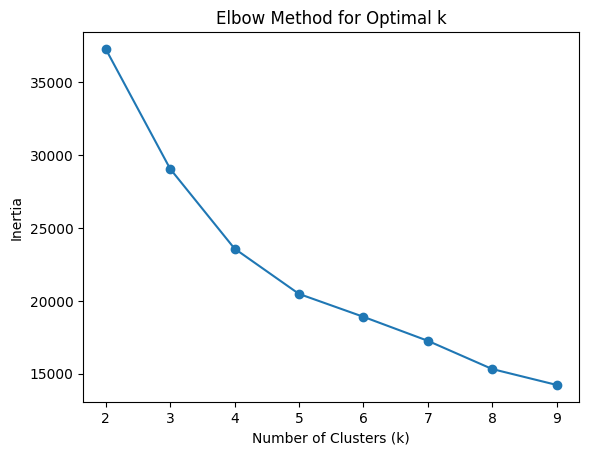

In [ ]:
from sklearn.cluster import KMeans

# Try different K values to find the best one
inertia = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scale)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()


<h4>The “elbow” point on the plot gives the best number of clusters</h4>
<h6>The inertia (within-cluster variance) drops sharply from k = 2 → 3 → 4,
But after k = 4, the decrease becomes gradual and almost linear.
This means the "elbow" point is around k = 4 — beyond that, adding more clusters gives little improvement in compactness.

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scale)


In [ ]:
cluster_summary = df.groupby('Cluster')[features].mean()
print(cluster_summary)

          Engine HP  Engine Cylinders  highway MPG          MSRP   Popularity
Cluster                                                                      
0        248.614650          5.672876    25.513413  33561.385805  3949.816692
1        167.164644          3.987299    31.713540  22671.187032  1118.289408
2        418.378096          7.876170    21.089158  63965.448335  1328.390754
3        253.231215          6.163369    23.099402  28899.662563  1057.486424


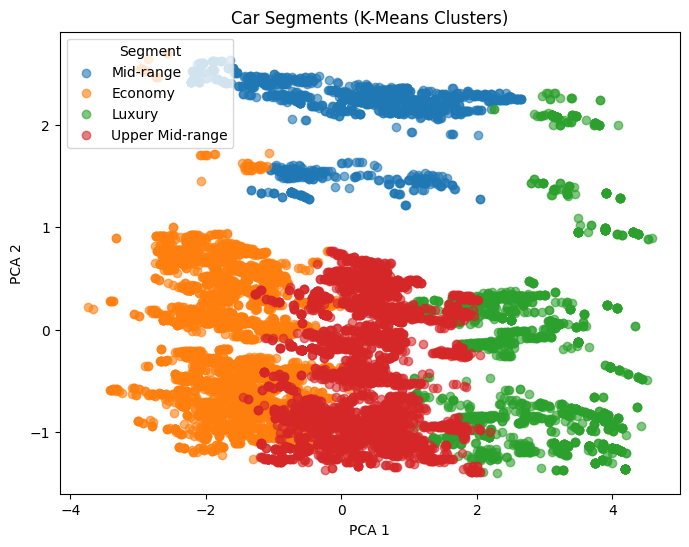

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1️⃣ Run PCA on your scaled features
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scale)   # X_scaled = your standardized data

# 2️⃣ Get your KMeans cluster labels
y_kmeans = kmeans.labels_

# 3️⃣ Define segment labels (based on your earlier cluster analysis)
cluster_labels = {
    0: "Mid-range",
    1: "Economy",
    2: "Luxury",
    3: "Upper Mid-range"
}

# 4️⃣ Plot clusters using PCA results
plt.figure(figsize=(8,6))
for cluster, label in cluster_labels.items():
    plt.scatter(
        pca_result[y_kmeans == cluster, 0],
        pca_result[y_kmeans == cluster, 1],
        label=label,
        alpha=0.6
    )

plt.title("Car Segments (K-Means Clusters)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Segment")
plt.show()


<h5>Using K-Means clustering on car performance and efficiency features (HP, cylinders, MPG, MSRP), the algorithm grouped cars into four clear segments.
After analyzing their average specs, we labeled these clusters as:

Economy: Low HP, high MPG, low price

Mid-range: Moderate HP and price

Upper Mid-range: Slightly higher performance but still affordable

Luxury: High HP, more cylinders, higher price

The PCA plot visualizes these clusters — each color corresponds to a market segment.</h5>

In [ ]:
cluster_summary = df_cluster.groupby("Segment")[["Engine HP", "Engine Cylinders", "highway MPG", "MSRP"]].mean()
cluster_summary


,Engine HP,Engine Cylinders,highway MPG,MSRP
Segment,,,,
Economy,167.164644,3.987299,31.713540,22671.187032
Luxury,418.378096,7.876170,21.089158,63965.448335
Mid-range,248.614650,5.672876,25.513413,33561.385805
Upper Mid-range,253.231215,6.163369,23.099402,28899.662563


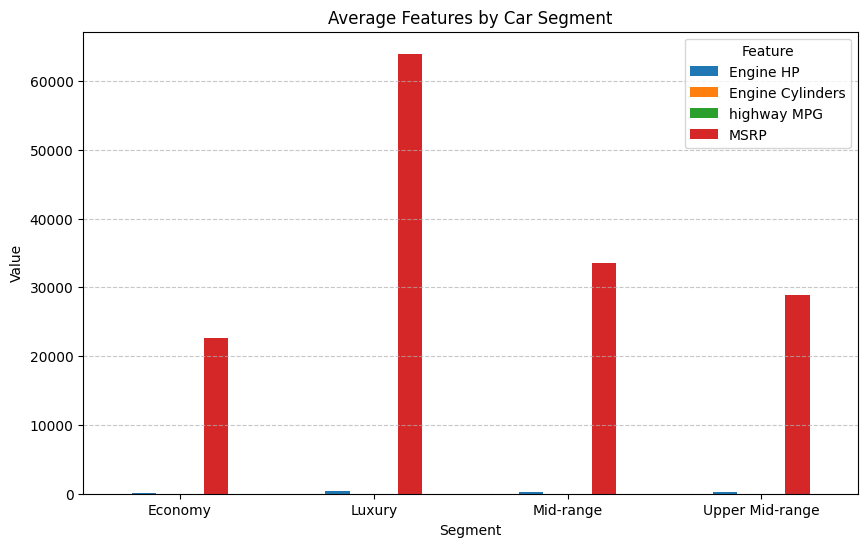

In [ ]:
cluster_summary.plot(kind="bar", figsize=(10,6))
plt.title("Average Features by Car Segment")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Feature")
plt.show()


<h4>
**Economy** :  Low HP, small engines, best fuel efficiency, lowest price            <br>
**Mid-range** : Balanced power and mileage, moderate cost    <br>                         
**Upper Mid-range** : Slightly more performance, moderate fuel economy           <br>           
**Luxury** : Very high power, many cylinders, low fuel efficiency, very high price
